# HyperTRIBE-seq RNA editing quantification

## Workflow

1. Make count matrices for each bam from alignment to host and viral reads
2. Quantify A-to-G transitions
    - Using a threshold of 1%-100% editing
    - 10 read minimum required for a given nucleotide position in both compared files
    - No threshold on Test vs Background editing enrichment
    - This gives any edit site above 1% that is expressed in all samples compared
    - Do with host and viral data
3. Merge bed files for each technical replicate
    - Each sample was compared, pairwise, to 1 of 3 control samples. So each replicate has 3 output beds
    - Merge these beds for each replicate
    - This gives all possible edit sites ≥1% that were expressed across test and control in a sample with no enrichment restrictions
4. Then merge biological replicate beds to make 1 file
    - Again no restrictions at this stage
    - This results in coordinates for any given site with ≥1% editing and expression in all control files for a given condition
5. Filter for sites occuring in all 3 reps for each condition, then overlap and save
6. Generate matrices that contain the coverage and mutation counts corresponding to each site determined in the previous step
7. Concatonate viral matrices onto host matrices
8. In R, use the count matrices to run a generalized linear model for determining signficant test vs ctl editing
9. Post-GLM, filter for sites determined to have test and control editing (shared sites from step 5)
    - With this filtered data, calculate the media log2FC for significant editing and apply this to all data. The lowest A-to-I editing rate in this subset will be used as the cutoff of all sites (including instances where no editing was detected in ADAR-ctl samples)

## 1. Make count matrices for each bam from alignment to host and viral reads

In [6]:
cd HCV

sbatch Make_matrix.sh

In [ ]:
cd host

sbatch Make_matrix.sh

## 2. Quantify A-to-G transitions

In [1]:
# Run with 1% thresholds on host data
cd /cwork/mt354/MGT279_TRIBE_SEQ/bullseye/host
inputs=/cwork/mt354/MGT279_TRIBE_SEQ/bullseye/host/matrix_files

sbatch -a 1-3 find_edits_01.sh \
$inputs/ifit3_1.markdup.sorted.matrix.gz \
$inputs/ctl_1.markdup.sorted.matrix.gz \
$inputs/ctl_2.markdup.sorted.matrix.gz \
$inputs/ctl_3.markdup.sorted.matrix.gz

sbatch -a 1-3 find_edits_01.sh \
$inputs/ifit3_2.markdup.sorted.matrix.gz \
$inputs/ctl_1.markdup.sorted.matrix.gz \
$inputs/ctl_2.markdup.sorted.matrix.gz \
$inputs/ctl_3.markdup.sorted.matrix.gz

sbatch -a 1-3 find_edits_01.sh \
$inputs/ifit3_3.markdup.sorted.matrix.gz \
$inputs/ctl_1.markdup.sorted.matrix.gz \
$inputs/ctl_2.markdup.sorted.matrix.gz \
$inputs/ctl_3.markdup.sorted.matrix.gz

sbatch -a 1-3 find_edits_01.sh \
$inputs/yth_1.markdup.sorted.matrix.gz \
$inputs/ctl_1.markdup.sorted.matrix.gz \
$inputs/ctl_2.markdup.sorted.matrix.gz \
$inputs/ctl_3.markdup.sorted.matrix.gz

sbatch -a 1-3 find_edits_01.sh \
$inputs/yth_2.markdup.sorted.matrix.gz \
$inputs/ctl_1.markdup.sorted.matrix.gz \
$inputs/ctl_2.markdup.sorted.matrix.gz \
$inputs/ctl_3.markdup.sorted.matrix.gz

sbatch -a 1-3 find_edits_01.sh \
$inputs/yth_3.markdup.sorted.matrix.gz \
$inputs/ctl_1.markdup.sorted.matrix.gz \
$inputs/ctl_2.markdup.sorted.matrix.gz \
$inputs/ctl_3.markdup.sorted.matrix.gz

sbatch -a 1-3 find_edits_01.sh \
$inputs/ctl_1.markdup.sorted.matrix.gz \
$inputs/ifit3_1.markdup.sorted.matrix.gz \
$inputs/ifit3_2.markdup.sorted.matrix.gz \
$inputs/ifit3_3.markdup.sorted.matrix.gz

sbatch -a 1-3 find_edits_01.sh \
$inputs/ctl_2.markdup.sorted.matrix.gz \
$inputs/ifit3_1.markdup.sorted.matrix.gz \
$inputs/ifit3_2.markdup.sorted.matrix.gz \
$inputs/ifit3_3.markdup.sorted.matrix.gz

sbatch -a 1-3 find_edits_01.sh \
$inputs/ctl_3.markdup.sorted.matrix.gz \
$inputs/ifit3_1.markdup.sorted.matrix.gz \
$inputs/ifit3_2.markdup.sorted.matrix.gz \
$inputs/ifit3_3.markdup.sorted.matrix.gz

sbatch -a 1-3 find_edits_01.sh \
$inputs/ctl_1.markdup.sorted.matrix.gz \
$inputs/yth_1.markdup.sorted.matrix.gz \
$inputs/yth_2.markdup.sorted.matrix.gz \
$inputs/yth_3.markdup.sorted.matrix.gz

sbatch -a 1-3 find_edits_01.sh \
$inputs/ctl_2.markdup.sorted.matrix.gz \
$inputs/yth_1.markdup.sorted.matrix.gz \
$inputs/yth_2.markdup.sorted.matrix.gz \
$inputs/yth_3.markdup.sorted.matrix.gz

sbatch -a 1-3 find_edits_01.sh \
$inputs/ctl_3.markdup.sorted.matrix.gz \
$inputs/yth_1.markdup.sorted.matrix.gz \
$inputs/yth_2.markdup.sorted.matrix.gz \
$inputs/yth_3.markdup.sorted.matrix.gz


Submitted batch job 31333694
Submitted batch job 31333695
Submitted batch job 31333696
Submitted batch job 31333697
Submitted batch job 31333698
Submitted batch job 31333699
Submitted batch job 31333700
Submitted batch job 31333715
Submitted batch job 31333716
Submitted batch job 31333717
Submitted batch job 31333718
Submitted batch job 31333719


In [2]:
# Run with 1% thresholds on host data
cd /cwork/mt354/MGT279_TRIBE_SEQ/bullseye/HCV
inputs=/cwork/mt354/MGT279_TRIBE_SEQ/bullseye/HCV/matrix_files

sbatch -a 1-3 find_edits_01.sh \
$inputs/ifit3_1.markdup.sorted.matrix.gz \
$inputs/ctl_1.markdup.sorted.matrix.gz \
$inputs/ctl_2.markdup.sorted.matrix.gz \
$inputs/ctl_3.markdup.sorted.matrix.gz

sbatch -a 1-3 find_edits_01.sh \
$inputs/ifit3_2.markdup.sorted.matrix.gz \
$inputs/ctl_1.markdup.sorted.matrix.gz \
$inputs/ctl_2.markdup.sorted.matrix.gz \
$inputs/ctl_3.markdup.sorted.matrix.gz

sbatch -a 1-3 find_edits_01.sh \
$inputs/ifit3_3.markdup.sorted.matrix.gz \
$inputs/ctl_1.markdup.sorted.matrix.gz \
$inputs/ctl_2.markdup.sorted.matrix.gz \
$inputs/ctl_3.markdup.sorted.matrix.gz

sbatch -a 1-3 find_edits_01.sh \
$inputs/yth_1.markdup.sorted.matrix.gz \
$inputs/ctl_1.markdup.sorted.matrix.gz \
$inputs/ctl_2.markdup.sorted.matrix.gz \
$inputs/ctl_3.markdup.sorted.matrix.gz

sbatch -a 1-3 find_edits_01.sh \
$inputs/yth_2.markdup.sorted.matrix.gz \
$inputs/ctl_1.markdup.sorted.matrix.gz \
$inputs/ctl_2.markdup.sorted.matrix.gz \
$inputs/ctl_3.markdup.sorted.matrix.gz

sbatch -a 1-3 find_edits_01.sh \
$inputs/yth_3.markdup.sorted.matrix.gz \
$inputs/ctl_1.markdup.sorted.matrix.gz \
$inputs/ctl_2.markdup.sorted.matrix.gz \
$inputs/ctl_3.markdup.sorted.matrix.gz

sbatch -a 1-3 find_edits_01.sh \
$inputs/ctl_1.markdup.sorted.matrix.gz \
$inputs/ifit3_1.markdup.sorted.matrix.gz \
$inputs/ifit3_2.markdup.sorted.matrix.gz \
$inputs/ifit3_3.markdup.sorted.matrix.gz

sbatch -a 1-3 find_edits_01.sh \
$inputs/ctl_2.markdup.sorted.matrix.gz \
$inputs/ifit3_1.markdup.sorted.matrix.gz \
$inputs/ifit3_2.markdup.sorted.matrix.gz \
$inputs/ifit3_3.markdup.sorted.matrix.gz

sbatch -a 1-3 find_edits_01.sh \
$inputs/ctl_3.markdup.sorted.matrix.gz \
$inputs/ifit3_1.markdup.sorted.matrix.gz \
$inputs/ifit3_2.markdup.sorted.matrix.gz \
$inputs/ifit3_3.markdup.sorted.matrix.gz

sbatch -a 1-3 find_edits_01.sh \
$inputs/ctl_1.markdup.sorted.matrix.gz \
$inputs/yth_1.markdup.sorted.matrix.gz \
$inputs/yth_2.markdup.sorted.matrix.gz \
$inputs/yth_3.markdup.sorted.matrix.gz

sbatch -a 1-3 find_edits_01.sh \
$inputs/ctl_2.markdup.sorted.matrix.gz \
$inputs/yth_1.markdup.sorted.matrix.gz \
$inputs/yth_2.markdup.sorted.matrix.gz \
$inputs/yth_3.markdup.sorted.matrix.gz

sbatch -a 1-3 find_edits_01.sh \
$inputs/ctl_3.markdup.sorted.matrix.gz \
$inputs/yth_1.markdup.sorted.matrix.gz \
$inputs/yth_2.markdup.sorted.matrix.gz \
$inputs/yth_3.markdup.sorted.matrix.gz

Submitted batch job 31333935
Submitted batch job 31333936
Submitted batch job 31333937
Submitted batch job 31333938
Submitted batch job 31333939
Submitted batch job 31333940
Submitted batch job 31333941
Submitted batch job 31333942
Submitted batch job 31333997
Submitted batch job 31333998
Submitted batch job 31333999
Submitted batch job 31334000


Clean up the directories before next step

In [3]:
cd /cwork/mt354/MGT279_TRIBE_SEQ/bullseye/HCV/edit_sites/beds

mkdir -p ctl_ifit3 ctl_yth ifit3 yth
mv ctl*ifit3*bed ctl_ifit3
mv ctl*yth*bed ctl_yth
mv ifit3*ctl*bed ifit3
mv yth*ctl*bed yth

In [4]:
cd /cwork/mt354/MGT279_TRIBE_SEQ/bullseye/host/edit_sites/beds

mkdir -p ctl_ifit3 ctl_yth ifit3 yth
mv ctl*ifit3*bed ctl_ifit3
mv ctl*yth*bed ctl_yth
mv ifit3*ctl*bed ifit3
mv yth*ctl*bed yth

## 3. Merge bed files for each technical replicate

In [5]:
cd /cwork/mt354/MGT279_TRIBE_SEQ/bullseye/host
bash summarize_sites.sh -h


Usage: summarize_sites.sh -s "stem1 stem2" -d /dest/path [other options]
Required:
  -s "stem1 stem2 ..."      List of sample name stems (quoted, space-separated)
  -d /dest/path             Output directory
Optional:
  -r MINREP                 --minRep (minimum number of replicates) [default: 3]
  -f FOLD                   --fold (min fold over control to keep sites) [default: 0]
  -c COVERAGE               --coverage (min coverage to keep site) [default: 10]
  -u MUT                    --mut (min # mutations per rep) [default: 0]
  -e EDIT                   --edit (min editing rate) [default: 0]
  -R                        --repOnly
  -b /beds/path             BED files directory [default: ]
  -h                        Show this help.



: 1

In [7]:
#merge all the host beds
beds=/cwork/mt354/MGT279_TRIBE_SEQ/bullseye/host/edit_sites/beds

sbatch summarize_sites.sh \
    -s "ifit3_1 ifit3_2 ifit3_3" \
    -b "${beds}/ifit3" \
    -d "${beds}/ifit3/combined_beds" \
    -r 3 -f 0 -c 10 -u 0 -e 0.01 -R

sbatch summarize_sites.sh \
    -s "yth_1 yth_2 yth_3" \
    -b "${beds}/yth" \
    -d "${beds}/yth/combined_beds" \
    -r 3 -f 0 -c 10 -u 0 -e 0.01 -R

sbatch summarize_sites.sh \
    -s "ctl_1 ctl_2 ctl_3" \
    -b "${beds}/ctl_ifit3" \
    -d "${beds}/ctl_ifit3/combined_beds" \
    -r 3 -f 0 -c 10 -u 0 -e 0.01 -R

sbatch summarize_sites.sh \
    -s "ctl_1 ctl_2 ctl_3" \
    -b "${beds}/ctl_yth" \
    -d "${beds}/ctl_yth/combined_beds" \
    -r 3 -f 0 -c 10 -u 0 -e 0.01 -R

Submitted batch job 31341282
Submitted batch job 31341283
Submitted batch job 31341284
Submitted batch job 31341285


In [10]:
# summarize for viral data
cd /cwork/mt354/MGT279_TRIBE_SEQ/bullseye/HCV
beds=/cwork/mt354/MGT279_TRIBE_SEQ/bullseye/HCV/edit_sites/beds

sbatch summarize_sites.sh \
    -s "ifit3_1 ifit3_2 ifit3_3" \
    -b "${beds}/ifit3" \
    -d "${beds}/ifit3/combined_beds" \
    -r 3 -f 0 -c 10 -u 0 -e 0.01 -R

sbatch summarize_sites.sh \
    -s "yth_1 yth_2 yth_3" \
    -b "${beds}/yth" \
    -d "${beds}/yth/combined_beds" \
    -r 3 -f 0 -c 10 -u 0 -e 0.01 -R

sbatch summarize_sites.sh \
    -s "ctl_1 ctl_2 ctl_3" \
    -b "${beds}/ctl_ifit3" \
    -d "${beds}/ctl_ifit3/combined_beds" \
    -r 3 -f 0 -c 10 -u 0 -e 0.01 -R

sbatch summarize_sites.sh \
    -s "ctl_1 ctl_2 ctl_3" \
    -b "${beds}/ctl_yth" \
    -d "${beds}/ctl_yth/combined_beds" \
    -r 3 -f 0 -c 10 -u 0 -e 0.01 -R



Submitted batch job 31342434
Submitted batch job 31342435
Submitted batch job 31342436
Submitted batch job 31342437


## 4. Then merge biological replicate beds to make 1 file

In [8]:
sbatch summarize_sites.sh \
    -s "ctl" \
    -b "${beds}/ctl_ifit3/combined_beds" \
    -d "${beds}/ctl_ifit3/combined_beds" \
    -r 1 -f 0 -c 10 -u 0 -e 0.01

sbatch summarize_sites.sh \
    -s "ctl" \
    -b "${beds}/ctl_yth/combined_beds" \
    -d "${beds}/ctl_yth/combined_beds" \
    -r 1 -f 0 -c 10 -u 0 -e 0.01

sbatch summarize_sites.sh \
    -s "ifit3" \
    -b "${beds}/ifit3/combined_beds" \
    -d "${beds}/ifit3/combined_beds" \
    -r 1 -f 0 -c 10 -u 0 -e 0.01

sbatch summarize_sites.sh \
    -s "yth" \
    -b "${beds}/yth/combined_beds" \
    -d "${beds}/yth/combined_beds" \
    -r 1 -f 0 -c 10 -u 0 -e 0.01

Submitted batch job 31341663
Submitted batch job 31341664
Submitted batch job 31341676
Submitted batch job 31341700


In [11]:
# summarize for viral data
cd /cwork/mt354/MGT279_TRIBE_SEQ/bullseye/HCV
beds=/cwork/mt354/MGT279_TRIBE_SEQ/bullseye/HCV/edit_sites/beds

sbatch summarize_sites.sh \
    -s "ifit3" \
    -b "${beds}/ifit3/combined_beds" \
    -d "${beds}/ifit3/combined_beds" \
    -r 1 -f 0 -c 10 -u 0 -e 0.01

sbatch summarize_sites.sh \
    -s "yth" \
    -b "${beds}/yth/combined_beds" \
    -d "${beds}/yth/combined_beds" \
    -r 1 -f 0 -c 10 -u 0 -e 0.01

sbatch summarize_sites.sh \
    -s "ctl" \
    -b "${beds}/ctl_ifit3/combined_beds" \
    -d "${beds}/ctl_ifit3/combined_beds" \
    -r 1 -f 0 -c 10 -u 0 -e 0.01

sbatch summarize_sites.sh \
    -s "ctl" \
    -b "${beds}/ctl_yth/combined_beds" \
    -d "${beds}/ctl_yth/combined_beds" \
    -r 1 -f 0 -c 10 -u 0 -e 0.01

Submitted batch job 31342596
Submitted batch job 31342597
Submitted batch job 31342598
Submitted batch job 31342599


## 5. Filter for sites occuring in all 3 reps for each condition, then overlap and save

Sites with rep=3 and same strand in ADAR-Ctl: 9475
Sites with rep=3 and same strand in IFIT3-ADAR: 14762
Shared: 6325
Unique to ADAR-Ctl: 3150
Unique to IFIT3-ADAR: 8437


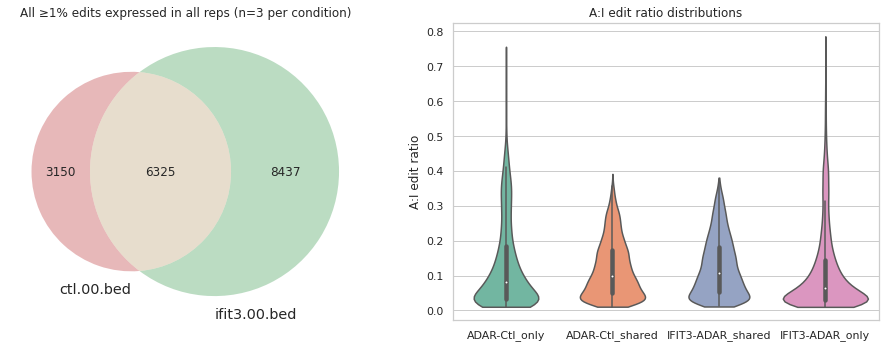

In [5]:
# Host data

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import seaborn as sns
work="/cwork/mt354/MGT279_TRIBE_SEQ/bullseye/host"
beds="/cwork/mt354/MGT279_TRIBE_SEQ/bullseye/host/edit_sites/beds"

# ==== Default text settings ====
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12


# ==== User: Set your file paths here ====
file1 = f"{beds}/ctl_ifit3/combined_beds/ctl.00.bed"
file2 = f"{beds}/ifit3/combined_beds/ifit3.00.bed"
label1="ADAR-Ctl"
label2="IFIT3-ADAR"
# ========================================

def read_filter_bed(filename):
    df = pd.read_csv(
        filename,
        sep='\t',
        header=None,
        dtype=str,
        comment='#'
    )
    df = df[df.iloc[:, -1] == '3'] #filter for sites that occurred across 3 reps
    df['site_id'] = df[0] + '_' + df[1] + '_' + df[2] + '_' + df[5]
    df = df.drop_duplicates(subset=['site_id'])
    df = df.set_index('site_id')
    return df

df1 = read_filter_bed(file1)
df2 = read_filter_bed(file2)

sites1 = set(df1.index)
sites2 = set(df2.index)

shared = sites1 & sites2
only1 = sites1 - sites2
only2 = sites2 - sites1

print(f"Sites with rep=3 and same strand in {label1}: {len(sites1)}")
print(f"Sites with rep=3 and same strand in {label2}: {len(sites2)}")
print(f"Shared: {len(shared)}")
print(f"Unique to {label1}: {len(only1)}")
print(f"Unique to {label2}: {len(only2)}")

# Column 5 is index 4
def get_col5(df, id_set):
    # Defensive: convert col 4 to numeric, coerce errors
    return pd.to_numeric(df.loc[list(id_set), 4], errors='coerce')

v1 = get_col5(df1, only1)
v2 = get_col5(df1, shared)
v3 = get_col5(df2, shared)
v4 = get_col5(df2, only2)


violin_df = pd.concat([
    pd.DataFrame({'Subset': f"{label1}_only", 'Value': v1}),
    pd.DataFrame({'Subset': f"{label1}_shared", 'Value': v2}),
    pd.DataFrame({'Subset': f"{label2}_shared", 'Value': v3}),
    pd.DataFrame({'Subset': f"{label2}_only", 'Value': v4}),
], ignore_index=True)
violin_df = violin_df.dropna(subset=['Value'])

# Compute the medians (rounded for clarity)
medians = violin_df.groupby('Subset')["Value"].median().round(4)

# --- Plot Venn diagram and violin plot side by side ---
sns.set(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(13,5))

# Venn diagram
venn2(subsets = (len(only1), len(only2), len(shared)),
      set_labels = (Path(file1).name, Path(file2).name),
      ax = ax1)
ax1.set_title("All ≥1% edits expressed in all reps (n=3 per condition)")

# Violin plot
sns.violinplot(data=violin_df, x='Subset', y='Value', inner='box', cut=0, ax=ax2, palette="Set2")
ax2.set_title("A:I edit ratio distributions")
ax2.set_xlabel("")
ax2.set_ylabel("A:I edit ratio")

plt.tight_layout()
plt.savefig(f'{work}/figures/output_figure_1.svg', bbox_inches='tight')
plt.show()

In [6]:
# Write bed files of the filtered subsets

# Get the original rows for each subset
df1_only = df1.loc[list(only1)].copy()
df_shared_ADAR = df1.loc[list(shared)].copy() #df1 for adar sites
df_shared_IFIT3 = df2.loc[list(shared)].copy() #df2 for ifit3 sites
df2_only = df2.loc[list(only2)].copy()

# Remove 'site_id' index for proper BED file writing
df1 = df1.reset_index(drop=True)
df1_only = df1_only.reset_index(drop=True)
df_shared_ADAR = df_shared_ADAR.reset_index(drop=True)
df_shared_IFIT3 = df_shared_IFIT3.reset_index(drop=True)
df2_only = df2_only.reset_index(drop=True)
df2 = df2.reset_index(drop=True)

# Write BED files
out0 = "ADAR_IFIT3_all.bed"
out1 = "ADAR_IFIT3_exc.bed"
outshared_1 = "ADAR_IFIT3_shared.bed"
outshared_2 = "IFIT3_ADAR_shared.bed"
out2 = "IFIT3_ADAR_exc.bed"
out3 = "IFIT3_ADAR_all.bed"

df1.to_csv(f"{work}/edit_sites/summary_beds/{out0}", sep='\t', header=False, index=False)
df1_only.to_csv(f"{work}/edit_sites/summary_beds/{out1}", sep='\t', header=False, index=False)
df_shared_ADAR.to_csv(f"{work}/edit_sites/summary_beds/{outshared_1}", sep='\t', header=False, index=False)
df_shared_IFIT3.to_csv(f"{work}/edit_sites/summary_beds/{outshared_2}", sep='\t', header=False, index=False)
df2_only.to_csv(f"{work}/edit_sites/summary_beds/{out2}", sep='\t', header=False, index=False)
df2.to_csv(f"{work}/edit_sites/summary_beds/{out3}", sep='\t', header=False, index=False)

print(f"Wrote {len(df1)} to {out0}")
print(f"Wrote {len(df2)} to {out3}")
print(f"Wrote {len(df1_only)} to {out1}")
print(f"Wrote {len(df2_only)} to {out2}")
print(f"Wrote {len(df_shared_ADAR)} {outshared_1}")
print(f"Wrote {len(df_shared_IFIT3)} {outshared_2}")

Wrote 9475 to ADAR_IFIT3_all.bed
Wrote 14762 to IFIT3_ADAR_all.bed
Wrote 3150 to ADAR_IFIT3_exc.bed
Wrote 8437 to IFIT3_ADAR_exc.bed
Wrote 6325 ADAR_IFIT3_shared.bed
Wrote 6325 IFIT3_ADAR_shared.bed


Sites with rep=3 and same strand in ADAR-Ctl: 9568
Sites with rep=3 and same strand in YTH-ADAR: 18695
Shared: 6308
Unique to ADAR-Ctl: 3260
Unique to YTH-ADAR: 12387


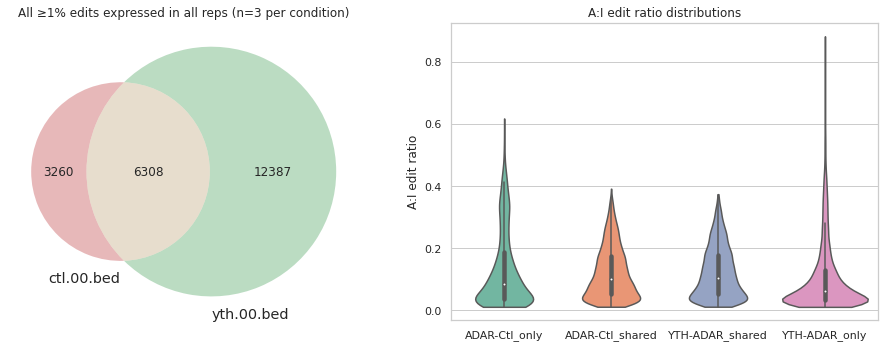

In [7]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import seaborn as sns
work="/cwork/mt354/MGT279_TRIBE_SEQ/bullseye/host"
beds="/cwork/mt354/MGT279_TRIBE_SEQ/bullseye/host/edit_sites/beds"

# ==== Default text settings ====
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12


# ==== User: Set your file paths here ====
file1 = f"{beds}/ctl_yth/combined_beds/ctl.00.bed"
file2 = f"{beds}/yth/combined_beds/yth.00.bed"
label1="ADAR-Ctl"
label2="YTH-ADAR"
# ========================================

def read_filter_bed(filename):
    df = pd.read_csv(
        filename,
        sep='\t',
        header=None,
        dtype=str,
        comment='#'
    )
    df = df[df.iloc[:, -1] == '3'] #filter for sites that occurred across 3 reps
    df['site_id'] = df[0] + '_' + df[1] + '_' + df[2] + '_' + df[5]
    df = df.drop_duplicates(subset=['site_id'])
    df = df.set_index('site_id')
    return df

df1 = read_filter_bed(file1)
df2 = read_filter_bed(file2)

sites1 = set(df1.index)
sites2 = set(df2.index)

shared = sites1 & sites2
only1 = sites1 - sites2
only2 = sites2 - sites1

print(f"Sites with rep=3 and same strand in {label1}: {len(sites1)}")
print(f"Sites with rep=3 and same strand in {label2}: {len(sites2)}")
print(f"Shared: {len(shared)}")
print(f"Unique to {label1}: {len(only1)}")
print(f"Unique to {label2}: {len(only2)}")

# Column 5 is index 4
def get_col5(df, id_set):
    # Defensive: convert col 4 to numeric, coerce errors
    return pd.to_numeric(df.loc[list(id_set), 4], errors='coerce')

v1 = get_col5(df1, only1)
v2 = get_col5(df1, shared)
v3 = get_col5(df2, shared)
v4 = get_col5(df2, only2)


violin_df = pd.concat([
    pd.DataFrame({'Subset': f"{label1}_only", 'Value': v1}),
    pd.DataFrame({'Subset': f"{label1}_shared", 'Value': v2}),
    pd.DataFrame({'Subset': f"{label2}_shared", 'Value': v3}),
    pd.DataFrame({'Subset': f"{label2}_only", 'Value': v4}),
], ignore_index=True)
violin_df = violin_df.dropna(subset=['Value'])

# Compute the medians (rounded for clarity)
medians = violin_df.groupby('Subset')["Value"].median().round(4)

# --- Plot Venn diagram and violin plot side by side ---
sns.set(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(13,5))

# Venn diagram
venn2(subsets = (len(only1), len(only2), len(shared)),
      set_labels = (Path(file1).name, Path(file2).name),
      ax = ax1)
ax1.set_title("All ≥1% edits expressed in all reps (n=3 per condition)")

# Violin plot
sns.violinplot(data=violin_df, x='Subset', y='Value', inner='box', cut=0, ax=ax2, palette="Set2")
ax2.set_title("A:I edit ratio distributions")
ax2.set_xlabel("")
ax2.set_ylabel("A:I edit ratio")

plt.tight_layout()
plt.savefig(f'{work}/figures/output_figure_2.svg', bbox_inches='tight')
plt.show()

In [8]:
# Write bed files of the filtered subsets

# Get the original rows for each subset
df1_only = df1.loc[list(only1)].copy()
df_shared_ADAR = df1.loc[list(shared)].copy() #df1 for adar sites
df_shared_IFIT3 = df2.loc[list(shared)].copy() #df2 for ifit3 sites
df2_only = df2.loc[list(only2)].copy()

# Remove 'site_id' index for proper BED file writing
df1 = df1.reset_index(drop=True)
df1_only = df1_only.reset_index(drop=True)
df_shared_ADAR = df_shared_ADAR.reset_index(drop=True)
df_shared_IFIT3 = df_shared_IFIT3.reset_index(drop=True)
df2_only = df2_only.reset_index(drop=True)
df2 = df2.reset_index(drop=True)

# Write BED files
out0 = "ADAR_YTH_all.bed"
out1 = "ADAR_YTH_exc.bed"
outshared_1 = "ADAR_YTH_shared.bed"
outshared_2 = "YTH_ADAR_shared.bed"
out2 = "YTH_ADAR_exc.bed"
out3 = "YTH_ADAR_all.bed"

df1.to_csv(f"{work}/edit_sites/summary_beds/{out0}", sep='\t', header=False, index=False)
df1_only.to_csv(f"{work}/edit_sites/summary_beds/{out1}", sep='\t', header=False, index=False)
df_shared_ADAR.to_csv(f"{work}/edit_sites/summary_beds/{outshared_1}", sep='\t', header=False, index=False)
df_shared_IFIT3.to_csv(f"{work}/edit_sites/summary_beds/{outshared_2}", sep='\t', header=False, index=False)
df2_only.to_csv(f"{work}/edit_sites/summary_beds/{out2}", sep='\t', header=False, index=False)
df2.to_csv(f"{work}/edit_sites/summary_beds/{out3}", sep='\t', header=False, index=False)

print(f"Wrote {len(df1)} to {out0}")
print(f"Wrote {len(df2)} to {out3}")
print(f"Wrote {len(df1_only)} to {out1}")
print(f"Wrote {len(df2_only)} to {out2}")
print(f"Wrote {len(df_shared_ADAR)} {outshared_1}")
print(f"Wrote {len(df_shared_IFIT3)} {outshared_2}")

Wrote 9568 to ADAR_YTH_all.bed
Wrote 18695 to YTH_ADAR_all.bed
Wrote 3260 to ADAR_YTH_exc.bed
Wrote 12387 to YTH_ADAR_exc.bed
Wrote 6308 ADAR_YTH_shared.bed
Wrote 6308 YTH_ADAR_shared.bed


Sites with rep=3 and same strand in ADAR-Ctl: 46
Sites with rep=3 and same strand in IFIT3-ADAR: 59
Shared: 42
Unique to ADAR-Ctl: 4
Unique to IFIT3-ADAR: 17


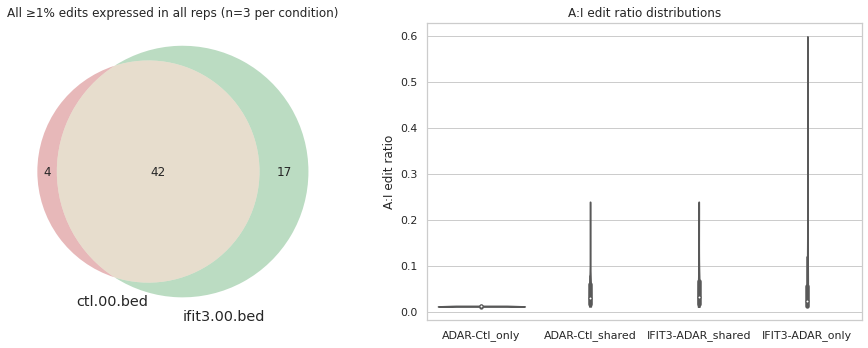

In [12]:
# Viral data

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import seaborn as sns
work="/cwork/mt354/MGT279_TRIBE_SEQ/bullseye/HCV"
beds="/cwork/mt354/MGT279_TRIBE_SEQ/bullseye/HCV/edit_sites/beds"

# ==== Default text settings ====
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12


# ==== User: Set your file paths here ====
file1 = f"{beds}/ctl_ifit3/combined_beds/ctl.00.bed"
file2 = f"{beds}/ifit3/combined_beds/ifit3.00.bed"
label1="ADAR-Ctl"
label2="IFIT3-ADAR"
# ========================================

def read_filter_bed(filename):
    df = pd.read_csv(
        filename,
        sep='\t',
        header=None,
        dtype=str,
        comment='#'
    )
    df = df[df.iloc[:, -1] == '3'] #filter for sites that occurred across 3 reps
    df['site_id'] = df[0] + '_' + df[1] + '_' + df[2] + '_' + df[5]
    df = df.drop_duplicates(subset=['site_id'])
    df = df.set_index('site_id')
    return df

df1 = read_filter_bed(file1)
df2 = read_filter_bed(file2)

sites1 = set(df1.index)
sites2 = set(df2.index)

shared = sites1 & sites2
only1 = sites1 - sites2
only2 = sites2 - sites1

print(f"Sites with rep=3 and same strand in {label1}: {len(sites1)}")
print(f"Sites with rep=3 and same strand in {label2}: {len(sites2)}")
print(f"Shared: {len(shared)}")
print(f"Unique to {label1}: {len(only1)}")
print(f"Unique to {label2}: {len(only2)}")

# Column 5 is index 4
def get_col5(df, id_set):
    # Defensive: convert col 4 to numeric, coerce errors
    return pd.to_numeric(df.loc[list(id_set), 4], errors='coerce')

v1 = get_col5(df1, only1)
v2 = get_col5(df1, shared)
v3 = get_col5(df2, shared)
v4 = get_col5(df2, only2)


violin_df = pd.concat([
    pd.DataFrame({'Subset': f"{label1}_only", 'Value': v1}),
    pd.DataFrame({'Subset': f"{label1}_shared", 'Value': v2}),
    pd.DataFrame({'Subset': f"{label2}_shared", 'Value': v3}),
    pd.DataFrame({'Subset': f"{label2}_only", 'Value': v4}),
], ignore_index=True)
violin_df = violin_df.dropna(subset=['Value'])

# Compute the medians (rounded for clarity)
medians = violin_df.groupby('Subset')["Value"].median().round(4)

# --- Plot Venn diagram and violin plot side by side ---
sns.set(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(13,5))

# Venn diagram
venn2(subsets = (len(only1), len(only2), len(shared)),
      set_labels = (Path(file1).name, Path(file2).name),
      ax = ax1)
ax1.set_title("All ≥1% edits expressed in all reps (n=3 per condition)")

# Violin plot
sns.violinplot(data=violin_df, x='Subset', y='Value', inner='box', cut=0, ax=ax2, palette="Set2")
ax2.set_title("A:I edit ratio distributions")
ax2.set_xlabel("")
ax2.set_ylabel("A:I edit ratio")

plt.tight_layout()
plt.savefig(f'{work}/figures/output_figure_1.svg', bbox_inches='tight')
plt.show()

In [13]:
# Write bed files of the filtered subsets

# Get the original rows for each subset
df1_only = df1.loc[list(only1)].copy()
df_shared_ADAR = df1.loc[list(shared)].copy() #df1 for adar sites
df_shared_IFIT3 = df2.loc[list(shared)].copy() #df2 for ifit3 sites
df2_only = df2.loc[list(only2)].copy()

# Remove 'site_id' index for proper BED file writing
df1 = df1.reset_index(drop=True)
df1_only = df1_only.reset_index(drop=True)
df_shared_ADAR = df_shared_ADAR.reset_index(drop=True)
df_shared_IFIT3 = df_shared_IFIT3.reset_index(drop=True)
df2_only = df2_only.reset_index(drop=True)
df2 = df2.reset_index(drop=True)

# Write BED files
out0 = "ADAR_IFIT3_all.bed"
out1 = "ADAR_IFIT3_exc.bed"
outshared_1 = "ADAR_IFIT3_shared.bed"
outshared_2 = "IFIT3_ADAR_shared.bed"
out2 = "IFIT3_ADAR_exc.bed"
out3 = "IFIT3_ADAR_all.bed"

df1.to_csv(f"{work}/edit_sites/summary_beds/{out0}", sep='\t', header=False, index=False)
df1_only.to_csv(f"{work}/edit_sites/summary_beds/{out1}", sep='\t', header=False, index=False)
df_shared_ADAR.to_csv(f"{work}/edit_sites/summary_beds/{outshared_1}", sep='\t', header=False, index=False)
df_shared_IFIT3.to_csv(f"{work}/edit_sites/summary_beds/{outshared_2}", sep='\t', header=False, index=False)
df2_only.to_csv(f"{work}/edit_sites/summary_beds/{out2}", sep='\t', header=False, index=False)
df2.to_csv(f"{work}/edit_sites/summary_beds/{out3}", sep='\t', header=False, index=False)

print(f"Wrote {len(df1)} to {out0}")
print(f"Wrote {len(df2)} to {out3}")
print(f"Wrote {len(df1_only)} to {out1}")
print(f"Wrote {len(df2_only)} to {out2}")
print(f"Wrote {len(df_shared_ADAR)} {outshared_1}")
print(f"Wrote {len(df_shared_IFIT3)} {outshared_2}")

Wrote 46 to ADAR_IFIT3_all.bed
Wrote 59 to IFIT3_ADAR_all.bed
Wrote 4 to ADAR_IFIT3_exc.bed
Wrote 17 to IFIT3_ADAR_exc.bed
Wrote 42 ADAR_IFIT3_shared.bed
Wrote 42 IFIT3_ADAR_shared.bed


Sites with rep=3 and same strand in ADAR-Ctl: 47
Sites with rep=3 and same strand in YTH-ADAR: 59
Shared: 44
Unique to ADAR-Ctl: 3
Unique to YTH-ADAR: 15


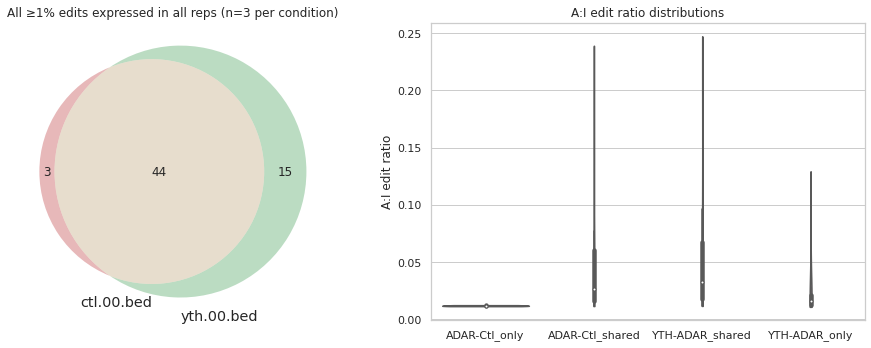

In [14]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import seaborn as sns
work="/cwork/mt354/MGT279_TRIBE_SEQ/bullseye/HCV"
beds="/cwork/mt354/MGT279_TRIBE_SEQ/bullseye/HCV/edit_sites/beds"

# ==== Default text settings ====
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12


# ==== User: Set your file paths here ====
file1 = f"{beds}/ctl_yth/combined_beds/ctl.00.bed"
file2 = f"{beds}/yth/combined_beds/yth.00.bed"
label1="ADAR-Ctl"
label2="YTH-ADAR"
# ========================================

def read_filter_bed(filename):
    df = pd.read_csv(
        filename,
        sep='\t',
        header=None,
        dtype=str,
        comment='#'
    )
    df = df[df.iloc[:, -1] == '3'] #filter for sites that occurred across 3 reps
    df['site_id'] = df[0] + '_' + df[1] + '_' + df[2] + '_' + df[5]
    df = df.drop_duplicates(subset=['site_id'])
    df = df.set_index('site_id')
    return df

df1 = read_filter_bed(file1)
df2 = read_filter_bed(file2)

sites1 = set(df1.index)
sites2 = set(df2.index)

shared = sites1 & sites2
only1 = sites1 - sites2
only2 = sites2 - sites1

print(f"Sites with rep=3 and same strand in {label1}: {len(sites1)}")
print(f"Sites with rep=3 and same strand in {label2}: {len(sites2)}")
print(f"Shared: {len(shared)}")
print(f"Unique to {label1}: {len(only1)}")
print(f"Unique to {label2}: {len(only2)}")

# Column 5 is index 4
def get_col5(df, id_set):
    # Defensive: convert col 4 to numeric, coerce errors
    return pd.to_numeric(df.loc[list(id_set), 4], errors='coerce')

v1 = get_col5(df1, only1)
v2 = get_col5(df1, shared)
v3 = get_col5(df2, shared)
v4 = get_col5(df2, only2)


violin_df = pd.concat([
    pd.DataFrame({'Subset': f"{label1}_only", 'Value': v1}),
    pd.DataFrame({'Subset': f"{label1}_shared", 'Value': v2}),
    pd.DataFrame({'Subset': f"{label2}_shared", 'Value': v3}),
    pd.DataFrame({'Subset': f"{label2}_only", 'Value': v4}),
], ignore_index=True)
violin_df = violin_df.dropna(subset=['Value'])

# Compute the medians (rounded for clarity)
medians = violin_df.groupby('Subset')["Value"].median().round(4)

# --- Plot Venn diagram and violin plot side by side ---
sns.set(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(13,5))

# Venn diagram
venn2(subsets = (len(only1), len(only2), len(shared)),
      set_labels = (Path(file1).name, Path(file2).name),
      ax = ax1)
ax1.set_title("All ≥1% edits expressed in all reps (n=3 per condition)")

# Violin plot
sns.violinplot(data=violin_df, x='Subset', y='Value', inner='box', cut=0, ax=ax2, palette="Set2")
ax2.set_title("A:I edit ratio distributions")
ax2.set_xlabel("")
ax2.set_ylabel("A:I edit ratio")

plt.tight_layout()
plt.savefig(f'{work}/figures/output_figure_2.svg', bbox_inches='tight')
plt.show()

In [15]:
# Write bed files of the filtered subsets

# Get the original rows for each subset
df1_only = df1.loc[list(only1)].copy()
df_shared_ADAR = df1.loc[list(shared)].copy() #df1 for adar sites
df_shared_IFIT3 = df2.loc[list(shared)].copy() #df2 for ifit3 sites
df2_only = df2.loc[list(only2)].copy()

# Remove 'site_id' index for proper BED file writing
df1 = df1.reset_index(drop=True)
df1_only = df1_only.reset_index(drop=True)
df_shared_ADAR = df_shared_ADAR.reset_index(drop=True)
df_shared_IFIT3 = df_shared_IFIT3.reset_index(drop=True)
df2_only = df2_only.reset_index(drop=True)
df2 = df2.reset_index(drop=True)

# Write BED files
out0 = "ADAR_YTH_all.bed"
out1 = "ADAR_YTH_exc.bed"
outshared_1 = "ADAR_YTH_shared.bed"
outshared_2 = "YTH_ADAR_shared.bed"
out2 = "YTH_ADAR_exc.bed"
out3 = "YTH_ADAR_all.bed"

df1.to_csv(f"{work}/edit_sites/summary_beds/{out0}", sep='\t', header=False, index=False)
df1_only.to_csv(f"{work}/edit_sites/summary_beds/{out1}", sep='\t', header=False, index=False)
df_shared_ADAR.to_csv(f"{work}/edit_sites/summary_beds/{outshared_1}", sep='\t', header=False, index=False)
df_shared_IFIT3.to_csv(f"{work}/edit_sites/summary_beds/{outshared_2}", sep='\t', header=False, index=False)
df2_only.to_csv(f"{work}/edit_sites/summary_beds/{out2}", sep='\t', header=False, index=False)
df2.to_csv(f"{work}/edit_sites/summary_beds/{out3}", sep='\t', header=False, index=False)

print(f"Wrote {len(df1)} to {out0}")
print(f"Wrote {len(df2)} to {out3}")
print(f"Wrote {len(df1_only)} to {out1}")
print(f"Wrote {len(df2_only)} to {out2}")
print(f"Wrote {len(df_shared_ADAR)} {outshared_1}")
print(f"Wrote {len(df_shared_IFIT3)} {outshared_2}")

Wrote 47 to ADAR_YTH_all.bed
Wrote 59 to YTH_ADAR_all.bed
Wrote 3 to ADAR_YTH_exc.bed
Wrote 15 to YTH_ADAR_exc.bed
Wrote 44 ADAR_YTH_shared.bed
Wrote 44 YTH_ADAR_shared.bed


## 6. Generate matrices that contain the coverage and mutation counts corresponding to each site determined in the previous step

In [1]:
cd /cwork/mt354/MGT279_TRIBE_SEQ/bullseye/host/

sbatch -a 0-5 quant_array_01_IFIT3_ADAR.sh
sbatch -a 0-5 quant_array_01_YTH_ADAR.sh

Submitted batch job 31350086
Submitted batch job 31350087


In [4]:
cd /cwork/mt354/MGT279_TRIBE_SEQ/bullseye/HCV/

sbatch -a 0-5 quant_array_01_IFIT3_ADAR.sh
sbatch -a 0-5 quant_array_01_YTH_ADAR.sh

Submitted batch job 31350192
Submitted batch job 31350193


In [10]:
cd /cwork/mt354/MGT279_TRIBE_SEQ/bullseye/host

sbatch ifit3_01_gather.sh
sbatch yth_01_gather.sh

Submitted batch job 31351395
Submitted batch job 31351396


In [12]:
cd /cwork/mt354/MGT279_TRIBE_SEQ/bullseye/HCV

sbatch ifit3_01_gather.sh
sbatch yth_01_gather.sh

Submitted batch job 31351439
Submitted batch job 31351440


## 7. Concatonate viral matrices onto host matrices

In [15]:
cd /cwork/mt354/MGT279_TRIBE_SEQ/bullseye/
# Set directory names
DIR_A="host/edit_sites/summary_beds"
DIR_B="HCV/edit_sites/summary_beds"
OUTPUT_DIR="combined/summary_beds"

# Create output directory if it doesn't exist
mkdir -p "$OUTPUT_DIR"

# Loop through each file in dir_A
for file in "${DIR_A}"/*; do
  filename=$(basename "$file")
  # Check if file also exists in dir_B
  if [ -f "$DIR_B/$filename" ]; then
    # Concatenate and write to combined/
    cat "$DIR_A/$filename" "$DIR_B/$filename" > "$OUTPUT_DIR/$filename"
  else
    echo "Warning: $filename not found in $DIR_B, skipping."
  fi
done

In [16]:
cd /cwork/mt354/MGT279_TRIBE_SEQ/bullseye/
# Set directory names
DIR_A="host/edit_sites/final_results"
DIR_B="HCV/edit_sites/final_results"
OUTPUT_DIR="combined/final_results"

# Create output directory if it doesn't exist
mkdir -p "$OUTPUT_DIR"

# Loop through each file in dir_A
for file in "${DIR_A}"/*; do
  filename=$(basename "$file")
  # Check if file also exists in dir_B
  if [ -f "$DIR_B/$filename" ]; then
    # Strip header from file 2 and concatenate to file 1 and write to combined/
    (head -n 1 "$DIR_A/$filename" && tail -n +2 "$DIR_A/$filename" && tail -n +2 "$DIR_B/$filename") > "$OUTPUT_DIR/$filename"
  else
    echo "Warning: $filename not found in $DIR_B, skipping."
  fi
done


## 8. In R, use the count matrices to run a generalized linear model for determining signficant test vs ctl editing
- See the corresponding .Rmd file and functions.R